# Near real-time HF-Radar currents in the proximity of the Deepwater Horizon site

Created: 2017-07-25

Updated: 2026-05-01

The explosion on the Deepwater Horizon (DWH) tragically killed 11 people, and resulted in one of the largest marine oil spills in history. One of the first questions when there is such a tragedy is: where will the oil go if that happened today?

In order the help answer that question one can use near real time currents from the HF-Radar sites near the incident.

First let's start with the [HF-Radar](https://hfradar.ioos.us/hfrnet/) site, where one can browse the available data interactively. Below we show an IFrame for the site.

In this notebook we will demonstrate how to obtain such data programmatically.

(For more information on the DWH see [https://response.restoration.noaa.gov/oil-and-chemical-spills/significant-incidents/deepwater-horizon-oil-spill](https://response.restoration.noaa.gov/oil-and-chemical-spills/significant-incidents/deepwater-horizon-oil-spill).

In [1]:
from IPython.display import IFrame

url = "https://hfradar.ioos.us/hfrnet/"

IFrame(
    src=url,
    width=750,
    height=450,
)

The interactive interface is handy for exploration but we usually need to download "mechanically" in order to use them in our analysis, plots, or for downloading time-series.

One way to achieve that is to use an OPeNDAP client, here Python's `xarray`, and explore the endpoints directly. The [NCEI `hfradar` catalog](https://www.ncei.noaa.gov/thredds-ocean/catalog/ioos/hfradar/rtv/catalog.html) is organized in folders and subfolders by year, month, region and then individual files that contains the datetime info and data resolution. The regions are:

- USWC &rarr; West Coast
- USHI &rarr; Hawaii
- USEGC &rarr; US East and Gulf Coasts
- PRVI &rarr; Puerto Rico/Virgin Islands
- AKNS &rarr; Alaska North Slope
- GLNA &rarr; Great Lakes North America
- GAK &rarr; Gulf of Alaska

Note that the region folders and file names can change from year to year. We will download data around 2017-07-25, the original data when this notebooks was first posted.

In [2]:
import xarray as xr

year, month = "2017", "07"
days = ["24", "25", "26"]
times = [f"{n:04}" for n in list(range(0, 2400, 100))]

urls = []
for day in days:
    for time in times:
        url = (
            "https://www.ncei.noaa.gov/thredds-ocean/dodsC/ioos/hfradar/rtv/"
            f"{year}/{year}{month}/USEGC/{year}{month}{day}{time}_hfr_usegc_6km_rtv_uwls_NDBC.nc"
        )
        urls.append(url)


# We need to use `preprocess` b/c not all coords, like `nSites`,
# align properly.
ds = xr.open_mfdataset(urls, preprocess=lambda ds: ds[["u", "v"]])
ds

<xarray.Dataset> Size: 186MB
Dimensions:  (time: 72, lat: 460, lon: 701)
Coordinates:
  * time     (time) datetime64[ns] 576B 2017-07-24 ... 2017-07-26T23:00:00
  * lat      (lat) float32 2kB 21.74 21.79 21.84 21.9 ... 46.39 46.44 46.49
  * lon      (lon) float32 3kB -97.88 -97.83 -97.77 ... -57.35 -57.29 -57.23
Data variables:
    u        (time, lat, lon) float32 93MB dask.array<chunksize=(1, 460, 701), meta=np.ndarray>
    v        (time, lat, lon) float32 93MB dask.array<chunksize=(1, 460, 701), meta=np.ndarray>
Attributes: (12/23)
    netcdf_library_version:          4.1.3
    format_version:                  HFRNet_1.0.0
    product_version:                 HFRNet_1.1.05
    Conventions:                     CF-1.1
    title:                           Near-Real Time Surface Ocean Velocity, U...
    institution:                     National Data Buoy Center
    ...                              ...
    grid_resolution:                 6km
    grid_projection:                 equidistant cylindrical
    regional_description:            Unites States, East and Gulf Coast
    DODS.strlen:                     25
    DODS.dimName:                    nSites_maxStrlen
    DODS_EXTRA.Unlimited_Dimension:  time

How about extracting a day time-series from the dataset and then averaged around the area of interest?

In [3]:
dx = dy = 2.25  # Area around the point of interest.
center = -87.373643, 29.061888  # Point of interest.

In [4]:
dsr = ds.sel(
    lon=(ds.lon < center[0] + dx) & (ds.lon > center[0] - dx),
    lat=(ds.lat < center[1] + dy) & (ds.lat > center[1] - dy),
)

avg = dsr.mean(dim=["lon", "lat"])
time = avg["time"].to_index().to_pydatetime()

Now all we have to do is mask the missing data with `NaN`s and average over the area.

In [5]:
import numpy.ma as ma

v = avg["v"].data
u = avg["u"].data

u = ma.masked_invalid(u)
v = ma.masked_invalid(v)

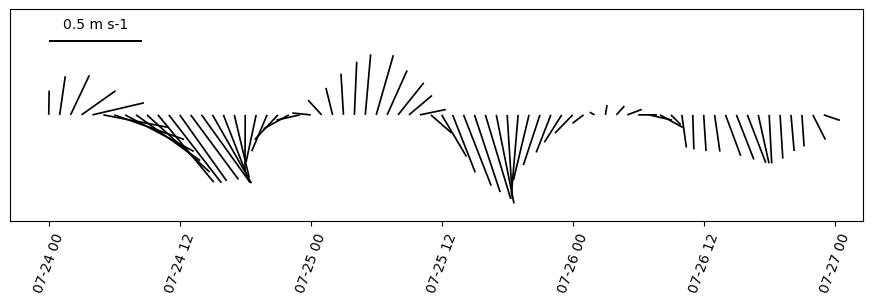

In [6]:
import matplotlib.pyplot as plt
from oceans.plotting import stick_plot

fig, ax = plt.subplots(figsize=(11, 2.75))

q = stick_plot(time, u, v, ax=ax)

ref = 0.5
qk = plt.quiverkey(
    q,
    0.1,
    0.85,
    ref,
    "{} {}".format(ref, ds["u"].units),
    labelpos="N",
    coordinates="axes",
)

_ = plt.xticks(rotation=70)

To close this post let's us reproduce the HF radar image from the interactive site using yesterday's data and the NRT endpoint from NDBC.

In [7]:
from datetime import date, timedelta

ds = xr.open_dataset(
    "https://dods.ndbc.noaa.gov/thredds/dodsC/hfradar_usegc_6km_25hravg"
)
yesterday = date.today() - timedelta(days=1)
dsy = ds.sel(time=yesterday, method="nearest")

Now that we singled out the date and and time we want the data, we trigger the download by accessing the data with `xarray`'s `.data` property.

In [8]:
u = dsy["u_mean"].data
v = dsy["v_mean"].data

lon = dsy.coords["lon"].data
lat = dsy.coords["lat"].data
time = dsy.coords["time"].data

The cell below computes the speed from the velocity. We can use the speed computation to color code the vectors. Note that we re-create the vector velocity preserving the direction but using intensity of `1`. (The same visualization technique used in the HF radar DAC.)

In [9]:
import numpy as np
from oceans.ocfis import spdir2uv, uv2spdir

angle, speed = uv2spdir(u, v)
us, vs = spdir2uv(np.ones_like(speed), angle, deg=True)

Now we can create a `matplotlib` figure displaying the data.

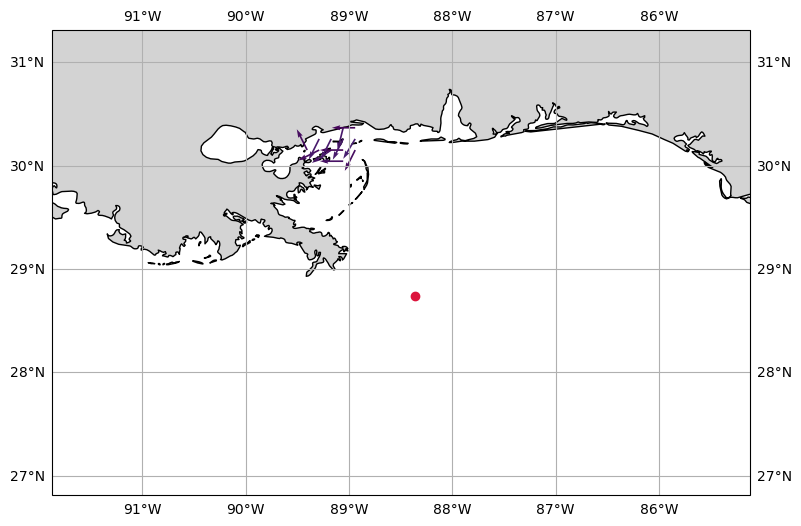

In [10]:
import cartopy.crs as ccrs
from cartopy import feature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER

LAND = feature.NaturalEarthFeature(
    "physical", "land", "10m", edgecolor="face", facecolor="lightgray"
)

sub = 2
bbox = lon.min(), lon.max(), lat.min(), lat.max()

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection=ccrs.PlateCarree()))


ax.set_extent([center[0] - dx - dx, center[0] + dx, center[1] - dy, center[1] + dy])
vmin, vmax = np.nanmin(speed[::sub, ::sub]), np.nanmax(speed[::sub, ::sub])
speed_clipped = np.clip(speed[::sub, ::sub], 0, 0.65)
ax.quiver(
    lon[::sub],
    lat[::sub],
    us[::sub, ::sub],
    vs[::sub, ::sub],
    speed_clipped,
    scale=30,
)

# Deepwater Horizon site.
ax.plot(-88.365997, 28.736628, marker="o", color="crimson")
gl = ax.gridlines(draw_labels=True)
gl.xlabels_top = gl.ylabels_right = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

feature = ax.add_feature(LAND, zorder=0, edgecolor="black")